# 1D-CNN v1 — Temporal Separable CNN with ECA

Treats sEMG as 8-channel time series instead of 8×50 image.
Conv1d along time axis, channel dimension preserved.

Setup per scenario:
- S1: standard (no aug)
- S2: calibration (train p0,p3,p6) + circular aug
- S3, S4, S5: standard (no aug)

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

from config import (
    MODELS_DIR, RANDOM_SEED, N_CLASSES, get_device,
    SUBJECTS_NON_FATIGUE, SUBJECTS_FATIGUE, SUBJECTS_INTERDAY_LONG,
)
from src.data_splitter import (
    load_metadata, load_windows_from_metadata,
    compute_normalization_stats, apply_normalization,
    scenario_1_ideal, scenario_3_inter_subject,
    scenario_4_interday, scenario_5_fatigue,
)
from src.evaluation import print_report, plot_confusion_matrix, measure_latency, print_latency

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
DEVICE = get_device()
print(f"Device: {DEVICE}")

Device: mps


## Model

In [2]:
class ECA1d(nn.Module):
    def __init__(self, channels, gamma=2, b=1):
        super().__init__()
        k = int(abs(math.log2(channels) / gamma + b / gamma))
        k = k if k % 2 else k + 1
        k = max(k, 3)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k, padding=k // 2, bias=False)

    def forward(self, x):
        # x: (B, C, T)
        b, c, t = x.size()
        w = self.gap(x).view(b, 1, c)          # (B, 1, C)
        w = torch.sigmoid(self.conv(w)).view(b, c, 1)  # (B, C, 1)
        return x * w.expand_as(x)


class SeparableConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=5, padding=2):
        super().__init__()
        self.depthwise = nn.Conv1d(in_ch, in_ch, kernel_size, padding=padding, groups=in_ch)
        self.pointwise = nn.Conv1d(in_ch, out_ch, kernel_size=1)
    def forward(self, x): return self.pointwise(self.depthwise(x))


class TemporalSCNN(nn.Module):
    def __init__(self, in_channels=8, n_classes=N_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: (B, 8, 50) -> (B, 64, 25)
            nn.Conv1d(in_channels, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(),
            ECA1d(64),
            nn.MaxPool1d(2),

            # Block 2: (B, 64, 25) -> (B, 128, 12)
            SeparableConv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128), nn.ReLU(),
            ECA1d(128),
            nn.MaxPool1d(2),

            # Block 3: (B, 128, 12) -> (B, 256, 1)
            SeparableConv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(),
            ECA1d(256),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        # x: (B, 8, 50) — no unsqueeze needed, 8 channels go directly into Conv1d
        return self.classifier(self.features(x))


model = TemporalSCNN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"TemporalSCNN Parameters: {n_params:,}")
print(f"2D-CNN had:              101,831")
print(f"2D-SCNN-ECA had:         44,764")
print(f"Reduction vs 2D-CNN:     {101831 / n_params:.1f}×")

TemporalSCNN Parameters: 62,676
2D-CNN had:              101,831
2D-SCNN-ECA had:         44,764
Reduction vs 2D-CNN:     1.6×


## Training utilities

In [3]:
def circular_augment(X, y, n_rotations=8):
    N, C, T = X.shape
    X_aug = np.empty((N * n_rotations, C, T), dtype=X.dtype)
    y_aug = np.empty(N * n_rotations, dtype=y.dtype)
    for shift in range(n_rotations):
        X_aug[shift * N:(shift + 1) * N] = np.roll(X, shift=shift, axis=1)
        y_aug[shift * N:(shift + 1) * N] = y
    idx = np.random.RandomState(RANDOM_SEED).permutation(len(y_aug))
    return X_aug[idx], y_aug[idx]


class NoisyDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, noise_std=0.1):
        self.X = torch.from_numpy(X).float()  # (N, 8, 50) — no unsqueeze for 1D
        self.y = torch.from_numpy(y).long()
        self.noise_std = noise_std
    def __len__(self): return len(self.y)
    def __getitem__(self, idx):
        x = self.X[idx]
        if self.noise_std > 0:
            x = x + torch.randn_like(x) * self.noise_std
        return x, self.y[idx]


def make_loader(X, y, noise_std=0.1, batch_size=256, shuffle=True):
    return DataLoader(NoisyDataset(X, y, noise_std), batch_size=batch_size, shuffle=shuffle)


def train_model(model, loader, n_epochs=50, lr=3e-3):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, epochs=n_epochs, steps_per_epoch=len(loader)
    )
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    for epoch in range(n_epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = model(xb)
            loss = criterion(out, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()
            total_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            total += xb.size(0)
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs} — loss: {total_loss/total:.4f}, acc: {correct/total:.4f}")


@torch.no_grad()
def predict(model, X):
    model.eval()
    X_t = torch.from_numpy(X).float()  # (N, 8, 50) — direct
    loader = DataLoader(TensorDataset(X_t), batch_size=512, shuffle=False)
    preds = []
    for (xb,) in loader:
        preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
    return np.concatenate(preds)


def train_and_eval(X_train, y_train, X_test, y_test, title, n_epochs=50, aug_circular=False):
    if aug_circular:
        X_train, y_train = circular_augment(X_train, y_train)
        print(f"After circular aug: {X_train.shape[0]:,} windows")
    loader = make_loader(X_train, y_train)
    model = TemporalSCNN().to(DEVICE)
    train_model(model, loader, n_epochs=n_epochs)
    y_pred = predict(model, X_test)
    metrics = print_report(y_test, y_pred, title=title)
    plot_confusion_matrix(y_test, y_pred, title=title)
    return model, metrics

---
## Scenario 1 — Ideal

In [4]:
X_train, y_train, X_test, y_test, info = scenario_1_ideal()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Loading windows: 100%|██████████| 251/251 [00:00<00:00, 1975.82it/s]


Train: (59159, 8, 50), Test: (29281, 8, 50)


Epoch   1/50 — loss: 1.8083, acc: 0.2866
Epoch   5/50 — loss: 1.1365, acc: 0.6772
Epoch  10/50 — loss: 0.8843, acc: 0.8100
Epoch  15/50 — loss: 0.7634, acc: 0.8720
Epoch  20/50 — loss: 0.6986, acc: 0.9023
Epoch  25/50 — loss: 0.6572, acc: 0.9216
Epoch  30/50 — loss: 0.6317, acc: 0.9338
Epoch  35/50 — loss: 0.6077, acc: 0.9442
Epoch  40/50 — loss: 0.5835, acc: 0.9547
Epoch  45/50 — loss: 0.5718, acc: 0.9601
Epoch  50/50 — loss: 0.5689, acc: 0.9613

  1D-CNN — S1 Ideal
  Accuracy:  0.7999
  F1-macro:  0.8009
                    precision    recall  f1-score   support

              fist       0.89      0.90      0.89      4208
         open_hand       0.80      0.75      0.77      4179
  pinch_forefinger       0.65      0.71      0.68      4204
pinch_middlefinger       0.74      0.74      0.74      4239
               two       0.80      0.80      0.80      4175
          eversion       0.85      0.85      0.85      4064
             varus       0.89      0.85      0.87      4212

      

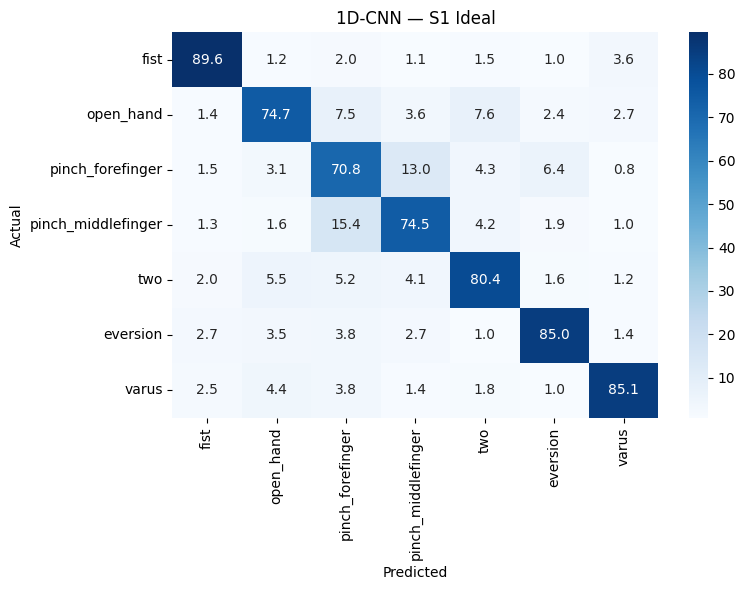

In [5]:
model_s1, metrics_s1 = train_and_eval(X_train, y_train, X_test, y_test, "1D-CNN — S1 Ideal")

In [6]:
# Per-subject evaluation
META = load_metadata()
subset = META[(META["session"] == 0) & (META["position"] == 0)]

per_subject_acc = {}
for subj in sorted(subset["subject"].unique()):
    subj_df = subset[subset["subject"] == subj]
    train_df = subj_df[subj_df["repetition"].isin([0, 1])]
    test_df = subj_df[subj_df["repetition"] == 2]

    X_tr, y_tr = load_windows_from_metadata(train_df, verbose=False)
    X_te, y_te = load_windows_from_metadata(test_df, verbose=False)

    mean, std = compute_normalization_stats(X_tr)
    X_tr = apply_normalization(X_tr, mean, std)
    X_te = apply_normalization(X_te, mean, std)

    m = TemporalSCNN().to(DEVICE)
    loader = make_loader(X_tr, y_tr, batch_size=128)
    train_model(m, loader, n_epochs=50, lr=3e-3)
    y_pred = predict(m, X_te)
    per_subject_acc[subj] = accuracy_score(y_te, y_pred)

accs = list(per_subject_acc.values())
print(f"\nPer-subject: mean={np.mean(accs):.4f}, min={np.min(accs):.4f}, max={np.max(accs):.4f}")
for subj, acc in sorted(per_subject_acc.items()):
    bar = "█" * int(acc * 40)
    print(f"  {subj:4s}: {acc:.3f} {bar}")

Epoch   1/50 — loss: 1.9365, acc: 0.1960
Epoch   5/50 — loss: 1.6437, acc: 0.5086
Epoch  10/50 — loss: 0.6846, acc: 0.9161
Epoch  15/50 — loss: 0.6379, acc: 0.9295
Epoch  20/50 — loss: 0.6126, acc: 0.9398
Epoch  25/50 — loss: 0.6055, acc: 0.9488
Epoch  30/50 — loss: 0.5919, acc: 0.9532
Epoch  35/50 — loss: 0.5526, acc: 0.9737
Epoch  40/50 — loss: 0.5453, acc: 0.9763
Epoch  45/50 — loss: 0.5224, acc: 0.9910
Epoch  50/50 — loss: 0.5241, acc: 0.9904
Epoch   1/50 — loss: 1.9367, acc: 0.1984
Epoch   5/50 — loss: 1.7610, acc: 0.3538
Epoch  10/50 — loss: 0.7850, acc: 0.8805
Epoch  15/50 — loss: 0.6105, acc: 0.9530
Epoch  20/50 — loss: 0.5783, acc: 0.9625
Epoch  25/50 — loss: 0.5514, acc: 0.9769
Epoch  30/50 — loss: 0.5241, acc: 0.9880
Epoch  35/50 — loss: 0.5085, acc: 0.9944
Epoch  40/50 — loss: 0.4976, acc: 0.9976
Epoch  45/50 — loss: 0.4974, acc: 0.9984
Epoch  50/50 — loss: 0.4938, acc: 0.9992
Epoch   1/50 — loss: 1.9263, acc: 0.1875
Epoch   5/50 — loss: 1.5842, acc: 0.3889
Epoch  10/50 — l

In [7]:
torch.save(model_s1.state_dict(), MODELS_DIR / "1dcnn_s1.pt")
print("Saved.")

Saved.


---
## Scenario 2 — Electrode Shift (calibration p0,p3,p6 + circular aug)

In [8]:
meta = load_metadata()
subset_s2 = meta[(meta["session"] == 0) & (meta["subject"].isin(SUBJECTS_NON_FATIGUE))]

TRAIN_POS = [0, 3, 6]
TEST_POS = [p for p in range(11) if p not in TRAIN_POS]

train_df = subset_s2[subset_s2["position"].isin(TRAIN_POS)]
X_train_s2, y_train_s2 = load_windows_from_metadata(train_df)
mean_s2, std_s2 = compute_normalization_stats(X_train_s2)
X_train_s2 = apply_normalization(X_train_s2, mean_s2, std_s2)
print(f"Train: {X_train_s2.shape}")

Loading windows: 100%|██████████| 1887/1887 [00:00<00:00, 2577.40it/s]


Train: (214696, 8, 50)


In [9]:
# Circular augmentation + train
X_s2_aug, y_s2_aug = circular_augment(X_train_s2, y_train_s2)
print(f"After aug: {X_s2_aug.shape[0]:,}")

model_s2 = TemporalSCNN().to(DEVICE)
loader_s2 = make_loader(X_s2_aug, y_s2_aug)
train_model(model_s2, loader_s2, n_epochs=50)

After aug: 1,717,568
Epoch   1/50 — loss: 1.6839, acc: 0.3662
Epoch   5/50 — loss: 1.2592, acc: 0.6145
Epoch  10/50 — loss: 1.1704, acc: 0.6618
Epoch  15/50 — loss: 1.1607, acc: 0.6671
Epoch  20/50 — loss: 1.1405, acc: 0.6774
Epoch  25/50 — loss: 1.1174, acc: 0.6892
Epoch  30/50 — loss: 1.0904, acc: 0.7032
Epoch  35/50 — loss: 1.0599, acc: 0.7188
Epoch  40/50 — loss: 1.0254, acc: 0.7364
Epoch  45/50 — loss: 0.9951, acc: 0.7516
Epoch  50/50 — loss: 0.9809, acc: 0.7585


In [10]:
acc_per_pos = {}
for pos in TEST_POS:
    pos_df = subset_s2[subset_s2["position"] == pos]
    X_p, y_p = load_windows_from_metadata(pos_df, verbose=False)
    X_p = apply_normalization(X_p, mean_s2, std_s2)
    y_pred = predict(model_s2, X_p)
    acc_per_pos[pos] = accuracy_score(y_p, y_pred)
    print(f"Position {pos:2d}: {acc_per_pos[pos]:.4f}")

avg_s2 = np.mean(list(acc_per_pos.values()))
print(f"\nS2 avg: {avg_s2:.4f}")

Position  1: 0.6447
Position  2: 0.6657
Position  4: 0.6763
Position  5: 0.6587
Position  7: 0.6542
Position  8: 0.6540
Position  9: 0.6641
Position 10: 0.6339

S2 avg: 0.6565


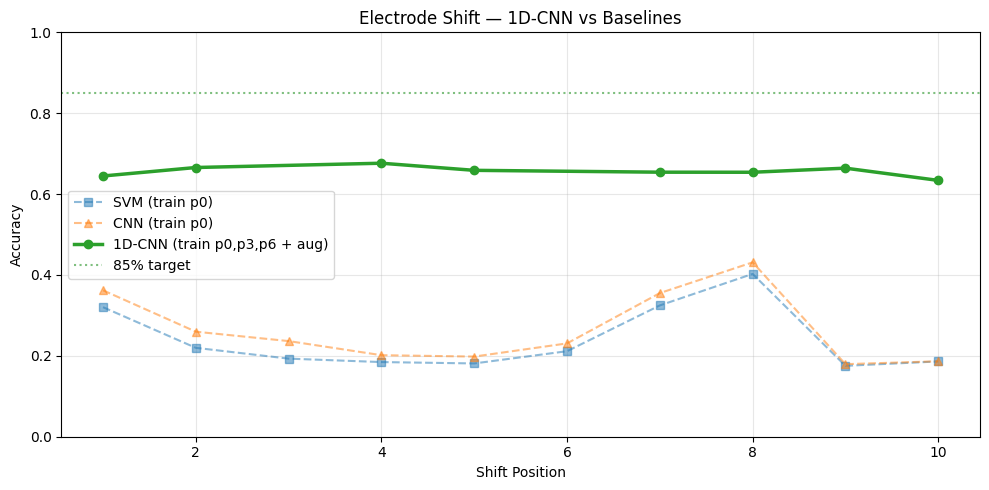

In [11]:
# Comparison plot
svm_s =  [0.3203, 0.2198, 0.1931, 0.1846, 0.1812, 0.2115, 0.3247, 0.4026, 0.1753, 0.1862]
cnn_s =  [0.3620, 0.2597, 0.2365, 0.2016, 0.1982, 0.2308, 0.3552, 0.4312, 0.1794, 0.1866]

plt.figure(figsize=(10, 5))
plt.plot(range(1,11), svm_s, "s--", label="SVM (train p0)", alpha=0.5)
plt.plot(range(1,11), cnn_s, "^--", label="CNN (train p0)", alpha=0.5)
plt.plot(TEST_POS, [acc_per_pos[p] for p in TEST_POS], "o-", label="1D-CNN (train p0,p3,p6 + aug)", linewidth=2.5)
plt.axhline(y=0.85, color="green", ls=":", alpha=0.5, label="85% target")
plt.xlabel("Shift Position")
plt.ylabel("Accuracy")
plt.title("Electrode Shift — 1D-CNN vs Baselines")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "1dcnn_shift.png"), dpi=150)
plt.show()

In [12]:
torch.save(model_s2.state_dict(), MODELS_DIR / "1dcnn_s2.pt")
print("Saved.")

Saved.


---
## Scenario 3 — Inter-Subject

In [13]:
X_train_s3, y_train_s3, X_test_s3, y_test_s3, info_s3 = scenario_3_inter_subject()
print(f"Train: {X_train_s3.shape} ({len(info_s3['train_subjects'])} subjects)")
print(f"Test:  {X_test_s3.shape} ({info_s3['test_subjects']})")

Loading windows: 100%|██████████| 1385/1385 [00:00<00:00, 2924.34it/s]


Train: (618926, 8, 50) (24 subjects)
Test:  (168232, 8, 50) (['h7', 'h22', 'h3', 'h24', 'h16', 'h17'])


Epoch   1/50 — loss: 1.7483, acc: 0.3164
Epoch   5/50 — loss: 1.2352, acc: 0.6247
Epoch  10/50 — loss: 1.0430, acc: 0.7272
Epoch  15/50 — loss: 0.9826, acc: 0.7605
Epoch  20/50 — loss: 0.9558, acc: 0.7735
Epoch  25/50 — loss: 0.9308, acc: 0.7864
Epoch  30/50 — loss: 0.9052, acc: 0.7991
Epoch  35/50 — loss: 0.8759, acc: 0.8137
Epoch  40/50 — loss: 0.8445, acc: 0.8290
Epoch  45/50 — loss: 0.8209, acc: 0.8406
Epoch  50/50 — loss: 0.8090, acc: 0.8463

  1D-CNN — S3 Inter-Subject
  Accuracy:  0.5044
  F1-macro:  0.4978
                    precision    recall  f1-score   support

              fist       0.59      0.51      0.55     23888
         open_hand       0.47      0.51      0.49     23933
  pinch_forefinger       0.38      0.34      0.36     24284
pinch_middlefinger       0.44      0.34      0.38     24064
               two       0.57      0.50      0.53     23897
          eversion       0.57      0.79      0.66     24069
             varus       0.48      0.55      0.51     24097

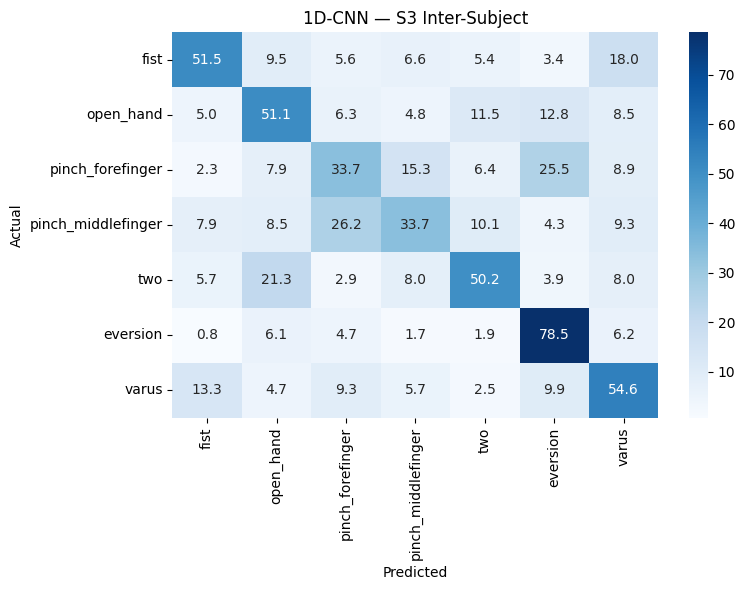

In [14]:
model_s3, metrics_s3 = train_and_eval(
    X_train_s3, y_train_s3, X_test_s3, y_test_s3,
    "1D-CNN — S3 Inter-Subject", n_epochs=50
)

In [15]:
torch.save(model_s3.state_dict(), MODELS_DIR / "1dcnn_s3.pt")
print("Saved.")

Saved.


---
## Scenario 4 — Inter-Day

In [16]:
X_train_s4, y_train_s4, test_by_sess, info_s4 = scenario_4_interday()
print(f"Train: {X_train_s4.shape}")

model_s4 = TemporalSCNN().to(DEVICE)
loader_s4 = make_loader(X_train_s4, y_train_s4)
train_model(model_s4, loader_s4, n_epochs=50)

Loading windows: 100%|██████████| 126/126 [00:00<00:00, 2275.31it/s]


Train: (13445, 8, 50)
Epoch   1/50 — loss: 1.9095, acc: 0.2178
Epoch   5/50 — loss: 1.1172, acc: 0.7003
Epoch  10/50 — loss: 0.7670, acc: 0.8720
Epoch  15/50 — loss: 0.6646, acc: 0.9272
Epoch  20/50 — loss: 0.6258, acc: 0.9416
Epoch  25/50 — loss: 0.6003, acc: 0.9537
Epoch  30/50 — loss: 0.5768, acc: 0.9611
Epoch  35/50 — loss: 0.5577, acc: 0.9691
Epoch  40/50 — loss: 0.5416, acc: 0.9767
Epoch  45/50 — loss: 0.5353, acc: 0.9790
Epoch  50/50 — loss: 0.5307, acc: 0.9807


Session 1: 0.6281
Session 2: 0.7162
Session 3: 0.6761
Session 4: 0.7217
Session 5: 0.6310
Session 6: 0.7244
Session 7: 0.6425
Session 8: 0.7422
Session 9: 0.5975

S4 avg: 0.6755


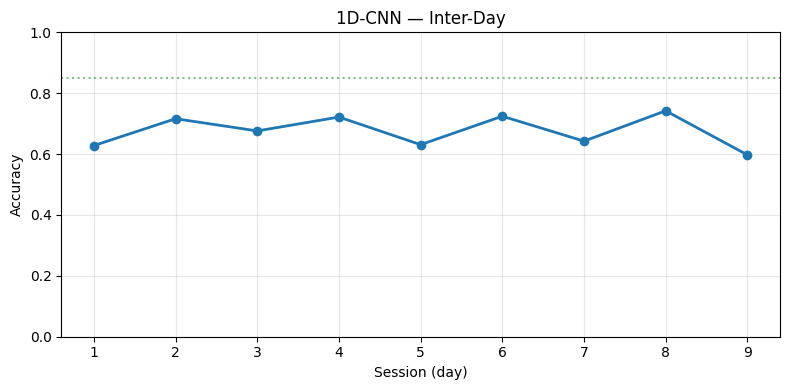

In [17]:
acc_per_sess = {}
for sess, (X_s, y_s) in sorted(test_by_sess.items()):
    y_pred = predict(model_s4, X_s)
    acc_per_sess[sess] = accuracy_score(y_s, y_pred)
    print(f"Session {sess}: {acc_per_sess[sess]:.4f}")

print(f"\nS4 avg: {np.mean(list(acc_per_sess.values())):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(acc_per_sess.keys()), list(acc_per_sess.values()), "o-", linewidth=2)
plt.axhline(y=0.85, color="green", ls=":", alpha=0.5)
plt.xlabel("Session (day)")
plt.ylabel("Accuracy")
plt.title("1D-CNN — Inter-Day")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "1dcnn_interday.png"), dpi=150)
plt.show()

---
## Scenario 5 — Fatigue

In [18]:
X_train_s5, y_train_s5, test_by_fatigue, info_s5 = scenario_5_fatigue()
print(f"Train: {X_train_s5.shape}")

model_s5 = TemporalSCNN().to(DEVICE)
loader_s5 = make_loader(X_train_s5, y_train_s5)
train_model(model_s5, loader_s5, n_epochs=50)

Loading windows: 100%|██████████| 252/252 [00:00<00:00, 2394.89it/s]


Train: (33046, 8, 50)
Epoch   1/50 — loss: 1.8168, acc: 0.3292
Epoch   5/50 — loss: 0.8460, acc: 0.8295
Epoch  10/50 — loss: 0.6913, acc: 0.9050
Epoch  15/50 — loss: 0.6323, acc: 0.9288
Epoch  20/50 — loss: 0.6025, acc: 0.9407
Epoch  25/50 — loss: 0.5772, acc: 0.9515
Epoch  30/50 — loss: 0.5626, acc: 0.9580
Epoch  35/50 — loss: 0.5469, acc: 0.9650
Epoch  40/50 — loss: 0.5346, acc: 0.9707
Epoch  45/50 — loss: 0.5240, acc: 0.9757
Epoch  50/50 — loss: 0.5218, acc: 0.9773


Position  2: 0.8899
Position  3: 0.8745
Position  4: 0.8785
Position  5: 0.8900
Position  6: 0.8791
Position  7: 0.8978
Position  8: 0.8512
Position  9: 0.8575
Position 10: 0.8372

S5 avg: 0.8729


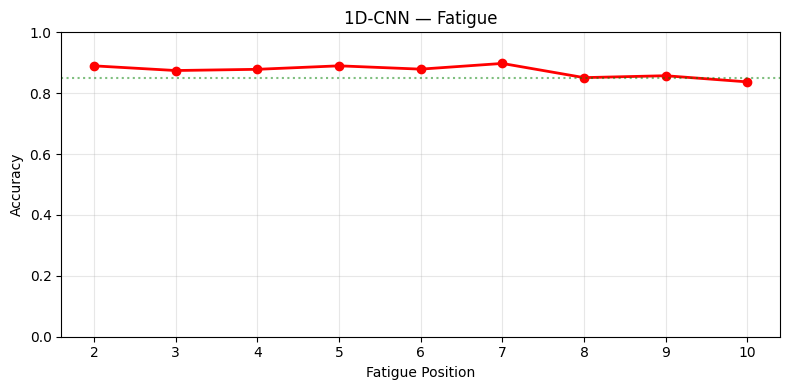

In [19]:
acc_per_fat = {}
for pos, (X_p, y_p) in sorted(test_by_fatigue.items()):
    y_pred = predict(model_s5, X_p)
    acc_per_fat[pos] = accuracy_score(y_p, y_pred)
    print(f"Position {pos:2d}: {acc_per_fat[pos]:.4f}")

print(f"\nS5 avg: {np.mean(list(acc_per_fat.values())):.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(acc_per_fat.keys()), list(acc_per_fat.values()), "o-", linewidth=2, color="red")
plt.axhline(y=0.85, color="green", ls=":", alpha=0.5)
plt.xlabel("Fatigue Position")
plt.ylabel("Accuracy")
plt.title("1D-CNN — Fatigue")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "1dcnn_fatigue.png"), dpi=150)
plt.show()

---
## Latency

In [20]:
model_s1.eval()
sample = torch.randn(1, 8, 50).to(DEVICE)
for _ in range(10):
    _ = model_s1(sample)
if DEVICE.type == "mps":
    torch.mps.synchronize()

def predict_single(x):
    x_t = torch.from_numpy(x).float().to(DEVICE)
    with torch.no_grad():
        out = model_s1(x_t)
    if DEVICE.type == "mps":
        torch.mps.synchronize()
    return out.argmax(1).cpu().numpy()

sample_np = np.random.randn(1, 8, 50).astype(np.float32)
latency = measure_latency(predict_single, sample_np, n_runs=500)
print_latency(latency, model_name="1D-CNN (direct inference, no FHT needed)")
print(f"Parameters: {sum(p.numel() for p in model_s1.parameters()):,}")


Latency — 1D-CNN (direct inference, no FHT needed)
  Mean:   2.70 ms
  Median: 2.77 ms
  P95:    3.03 ms
  <300ms: ✓
Parameters: 62,676


---
## Full Comparison

In [21]:
n_params = sum(p.numel() for p in model_s1.parameters())

print("\n" + "=" * 75)
print("FULL COMPARISON — ALL METHODS")
print("=" * 75)
print(f"{'Metric':<22} {'SVM':>8} {'2D-CNN':>8} {'SCNN-ECA':>8} {'1D-CNN':>8}")
print("-" * 75)
print(f"{'S1 Ideal':<22} {'65.19%':>8} {'75.78%':>8} {'76.32%':>8} {metrics_s1['accuracy']*100:>7.2f}%")
print(f"{'S1 Per-subj':<22} {'77.70%':>8} {'—':>8} {'81.75%':>8} {np.mean(accs)*100:>7.2f}%")
print(f"{'S2 Shift (cal)':<22} {'23.99%':>8} {'26.41%':>8} {'57.18%':>8} {avg_s2*100:>7.2f}%")
print(f"{'S3 Inter-subject':<22} {'40.27%':>8} {'52.90%':>8} {'51.15%':>8} {metrics_s3['accuracy']*100:>7.2f}%")
print(f"{'S4 Inter-day':<22} {'63.03%':>8} {'67.30%':>8} {'61.22%':>8} {np.mean(list(acc_per_sess.values()))*100:>7.2f}%")
print(f"{'S5 Fatigue':<22} {'81.20%':>8} {'86.98%':>8} {'85.10%':>8} {np.mean(list(acc_per_fat.values()))*100:>7.2f}%")
print(f"{'Latency p95 (ms)':<22} {'5.40':>8} {'1.74':>8} {'1.47':>8} {latency['p95_ms']:>7.2f}")
print(f"{'Parameters':<22} {'—':>8} {'101,831':>8} {'44,764':>8} {n_params:>8,}")
print("=" * 75)
print(f"\nNote: S2 for SVM/CNN uses train-p0-only setup.")
print(f"      S2 for SCNN-ECA and 1D-CNN uses calibration (train p0,p3,p6 + circular aug).")
print(f"      1D-CNN processes raw signal directly — no FHT needed.")


FULL COMPARISON — ALL METHODS
Metric                      SVM   2D-CNN SCNN-ECA   1D-CNN
---------------------------------------------------------------------------
S1 Ideal                 65.19%   75.78%   76.32%   79.99%
S1 Per-subj              77.70%        —   81.75%   81.06%
S2 Shift (cal)           23.99%   26.41%   57.18%   65.65%
S3 Inter-subject         40.27%   52.90%   51.15%   50.44%
S4 Inter-day             63.03%   67.30%   61.22%   67.55%
S5 Fatigue               81.20%   86.98%   85.10%   87.29%
Latency p95 (ms)           5.40     1.74     1.47    3.03
Parameters                    —  101,831   44,764   62,676

Note: S2 for SVM/CNN uses train-p0-only setup.
      S2 for SCNN-ECA and 1D-CNN uses calibration (train p0,p3,p6 + circular aug).
      1D-CNN processes raw signal directly — no FHT needed.
